# Notebook 05 — XGBoost Model

**Goal**: Train XGBoost across all walk-forward folds and evaluate predictive performance.

---

## Why XGBoost?

XGBoost (eXtreme Gradient Boosting) is one of the most successful ML algorithms for tabular data:

- **Gradient boosting**: Builds trees sequentially, each correcting errors of the previous
- **Regularization**: L1/L2 penalties prevent overfitting
- **Missing values**: Handles NaN natively
- **Feature importance**: Built-in SHAP support
- **Fast**: Parallelized and cache-efficient

### How Gradient Boosting Works

At iteration $m$, we fit a new tree $h_m$ to the **negative gradient** (residuals) of the loss:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where $\eta$ is the learning rate (we use 0.05 — slow learning = better generalization).

### Our Configuration

| Parameter | Value | Why |
|-----------|-------|-----------|
| n_estimators | 1000 | Enough trees with early stopping |
| learning_rate | 0.05 | Slow but stable |
| max_depth | 6 | Prevent overly complex trees |
| subsample | 0.8 | Row sampling → reduces overfitting |
| colsample_bytree | 0.8 | Column sampling → like random forests |
| early_stopping | 50 rounds | Stop if no improvement |
| eval_metric | RMSE | For regression; logloss for classification |

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

from src.backtest import WalkForwardCV
from src.models import XGBoostModel
from src.features.pipeline import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Processed Data

We load the feature-engineered data from Notebook 03.

In [2]:
# Load all processed data (only ticker files, skip prediction files)
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.NS.parquet"))

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

print(f"Loaded {len(all_data)} tickers")

# Use ALL tickers for training
sample_tickers = list(all_data.keys())
print(f"Training on {len(sample_tickers)} tickers")

Loaded 122 tickers
Training on 122 tickers


## Step 2 — Prepare Features and Targets

In [3]:
# Use FeaturePipeline's feature column selection
pipeline = FeaturePipeline()
target_horizon = 5  # Predict 5-day return

# STEP 1: Compute COMMON feature columns (intersection across ALL tickers)
# This prevents NaN-filled columns from tickers missing features
all_feature_sets = []
for ticker in list(all_data.keys()):
    df = all_data[ticker]
    cols = pipeline.get_feature_columns(df)
    all_feature_sets.append(set(cols))

# Use intersection — only features present in ALL tickers
common_features = sorted(set.intersection(*all_feature_sets))
print(f"Common features across {len(all_feature_sets)} tickers: {len(common_features)}")

# STEP 2: Combine data from multiple tickers (panel approach)
all_features = []
all_targets = []

sample_tickers = list(all_data.keys())

for ticker in sample_tickers:
    df = all_data[ticker]
    feature_cols = common_features  # Use COMMON features, not per-ticker
    
    # Create target: forward return
    target = df["Close"].shift(-target_horizon) / df["Close"] - 1
    valid = target.dropna().index
    valid = valid.intersection(df.dropna(subset=feature_cols).index)
    
    if len(valid) > 200:
        feat_df = df.loc[valid, feature_cols].copy()
        feat_df["_ticker"] = ticker
        feat_df["_date"] = feat_df.index
        all_features.append(feat_df)
        all_targets.append(target.loc[valid])

# Combine and reset index to avoid duplicate date issues
X_all = pd.concat(all_features).reset_index(drop=True)
y_all = pd.concat(all_targets).reset_index(drop=True)

# Store date column separately for sorting, then drop metadata cols
dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]
X_all = X_all.drop(columns=["_ticker", "_date"])

# Replace inf/-inf with NaN, then fill remaining NaN with 0
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(0)

# Sort by date
sort_order = dates_col.argsort()
X_all = X_all.iloc[sort_order].reset_index(drop=True)
y_all = y_all.iloc[sort_order].reset_index(drop=True)
dates_col = dates_col.iloc[sort_order].reset_index(drop=True)

print(f"Total samples:  {len(X_all):,}")
print(f"Total features: {len(X_all.columns)}")
print(f"Date range:     {dates_col.min().date()} → {dates_col.max().date()}")
print(f"Target mean:    {y_all.mean():.4f}")
print(f"Target std:     {y_all.std():.4f}")

Common features across 122 tickers: 206
Total samples:  246,508
Total features: 206
Date range:     2017-03-03 → 2026-02-02
Target mean:    0.0048
Target std:     0.0492


## Step 3 — Walk-Forward Training

For each fold:
1. Split data into train/test using walk-forward indices
2. Train XGBoost with early stopping on a validation set
3. Predict on test set
4. Record metrics

This is the most important step — every prediction is made on **truly out-of-sample** data.

In [4]:
# Date-based walk-forward CV for panel data (EXPANDING WINDOW)
# WalkForwardCV's row-based windows don't work well with multi-ticker panel data
# Instead, split by calendar dates: expanding train → gap → 3-month test

unique_dates = sorted(dates_col.unique())
n_dates = len(unique_dates)

train_days = 504   # ~2 years minimum training days  
test_days = 63     # ~3 months
embargo_days = 5   # gap between train and test
step_days = 63     # step forward by 3 months each fold (expanding window)

fold_results = []
fold_predictions = []
fold_num = 0

idx = 0
while idx + train_days + embargo_days + test_days <= n_dates:
    fold_num += 1
    
    train_end_idx = idx + train_days
    test_start_idx = train_end_idx + embargo_days
    test_end_idx = test_start_idx + test_days
    
    if test_end_idx > n_dates:
        break
    
    # EXPANDING WINDOW: always start training from date 0
    train_dates_set = set(unique_dates[0:train_end_idx])
    test_dates_set = set(unique_dates[test_start_idx:test_end_idx])
    
    train_mask = dates_col.isin(train_dates_set)
    test_mask = dates_col.isin(test_dates_set)
    
    X_train = X_all[train_mask.values]
    y_train = y_all[train_mask.values]
    X_test = X_all[test_mask.values]
    y_test = y_all[test_mask.values]
    
    if len(X_train) < 200 or len(X_test) < 30:
        idx += step_days
        continue
    
    print(f"\n--- Fold {fold_num} ---")
    print(f"  Train: {unique_dates[0].date()} → {unique_dates[train_end_idx-1].date()} ({len(X_train):,} samples)")
    print(f"  Test:  {unique_dates[test_start_idx].date()} → {unique_dates[min(test_end_idx-1, n_dates-1)].date()} ({len(X_test):,} samples)")
    
    # Create a fresh model per fold
    model = XGBoostModel(task="regression")
    
    # Split last 15% of training data as validation for early stopping
    val_size = max(int(len(X_train) * 0.15), 100)
    X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
    y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
    
    # Train with early stopping
    metrics = model.fit(X_tr, y_tr, X_val, y_val)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    direction_acc = accuracy_score(y_test > 0, y_pred > 0)
    
    fold_results.append({
        "fold": fold_num,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "direction_accuracy": direction_acc,
        "n_train": len(X_tr),
        "n_val": len(X_val),
        "n_test": len(X_test),
        "best_iteration": metrics.get("best_iteration", "N/A"),
    })
    
    test_dates_vals = dates_col[test_mask.values]
    test_tickers_vals = tickers_col[test_mask.values]
    fold_predictions.append(pd.DataFrame({
        "date": test_dates_vals.values,
        "Ticker": test_tickers_vals.values,
        "actual": y_test.values,
        "predicted": y_pred,
        "fold": fold_num,
    }))
    
    print(f"  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}  Dir Acc: {direction_acc:.1%}")
    print(f"  Best iteration: {metrics.get('best_iteration', 'N/A')}")
    
    idx += step_days

results_df = pd.DataFrame(fold_results)
print(f"\n{'='*60}")
print(f"AVERAGE ACROSS {len(fold_results)} FOLDS:")
print(f"  RMSE:              {results_df['rmse'].mean():.4f}  ± {results_df['rmse'].std():.4f}")
print(f"  MAE:               {results_df['mae'].mean():.4f}  ± {results_df['mae'].std():.4f}")
print(f"  R²:                {results_df['r2'].mean():.4f}  ± {results_df['r2'].std():.4f}")
print(f"  Direction Accuracy: {results_df['direction_accuracy'].mean():.1%}  ± {results_df['direction_accuracy'].std():.1%}")


--- Fold 1 ---
  Train: 2017-03-03 → 2019-03-15 (50,634 samples)
  Test:  2019-03-26 → 2019-06-28 (6,713 samples)
  RMSE: 0.0453  MAE: 0.0326  R²: -0.0445  Dir Acc: 50.6%
  Best iteration: 90

--- Fold 2 ---
  Train: 2017-03-03 → 2019-06-21 (57,337 samples)
  Test:  2019-07-01 → 2019-10-01 (6,798 samples)
  RMSE: 0.0535  MAE: 0.0394  R²: -0.0249  Dir Acc: 42.4%
  Best iteration: 7

--- Fold 3 ---
  Train: 2017-03-03 → 2019-09-24 (64,130 samples)
  Test:  2019-10-03 → 2020-01-03 (6,804 samples)
  RMSE: 0.0468  MAE: 0.0314  R²: -0.0170  Dir Acc: 55.3%
  Best iteration: 6

--- Fold 4 ---
  Train: 2017-03-03 → 2019-12-27 (70,934 samples)
  Test:  2020-01-06 → 2020-04-07 (6,804 samples)
  RMSE: 0.0912  MAE: 0.0655  R²: -0.1440  Dir Acc: 41.0%
  Best iteration: 45

--- Fold 5 ---
  Train: 2017-03-03 → 2020-03-27 (77,738 samples)
  Test:  2020-04-08 → 2020-07-09 (6,893 samples)
  RMSE: 0.0690  MAE: 0.0506  R²: -0.0356  Dir Acc: 56.7%
  Best iteration: 0

--- Fold 6 ---
  Train: 2017-03-03 → 

## Step 4 — Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) tells us **which features** drive predictions.

- **High |SHAP value|** → feature strongly influences prediction
- **Red color** = high feature value, **Blue** = low feature value
- This helps us understand what the model learned

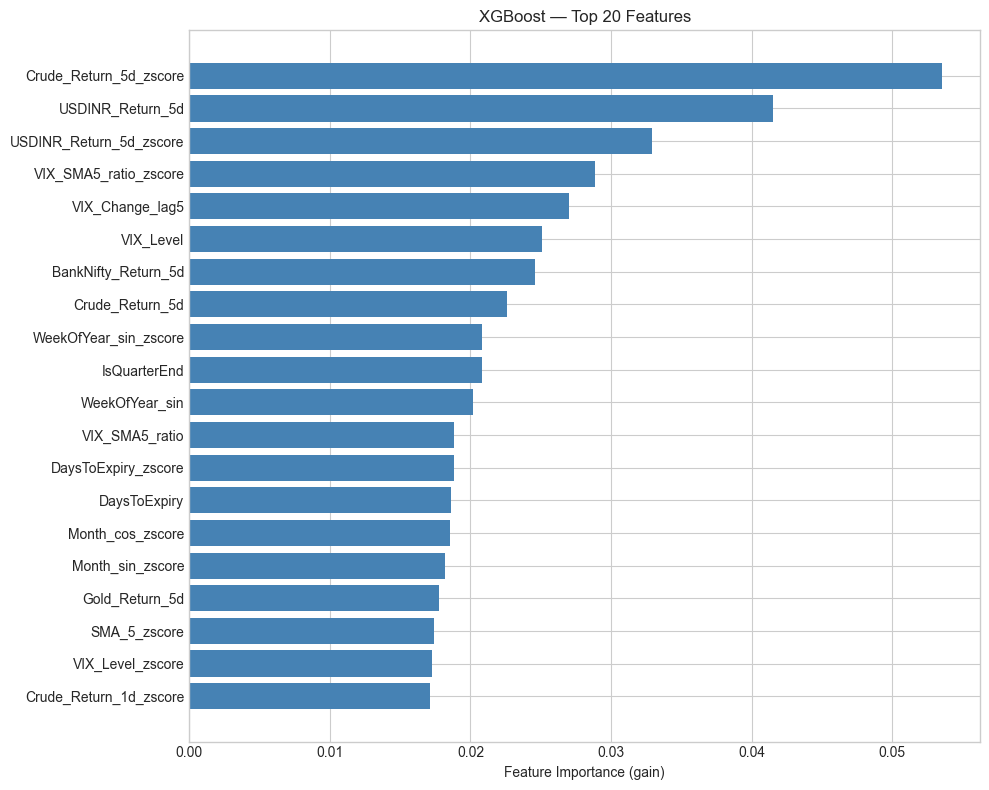

In [5]:
# Feature importance from the last fold's model (no arguments needed)
importance = model.feature_importance()

if importance is not None:
    # Plot top 20
    top20 = importance.head(20)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(top20)), top20.values, color="steelblue")
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index)
    ax.set_xlabel("Feature Importance (gain)")
    ax.set_title("XGBoost — Top 20 Features")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 5 — Prediction Analysis

Let's visualize how well our predictions track actual returns.

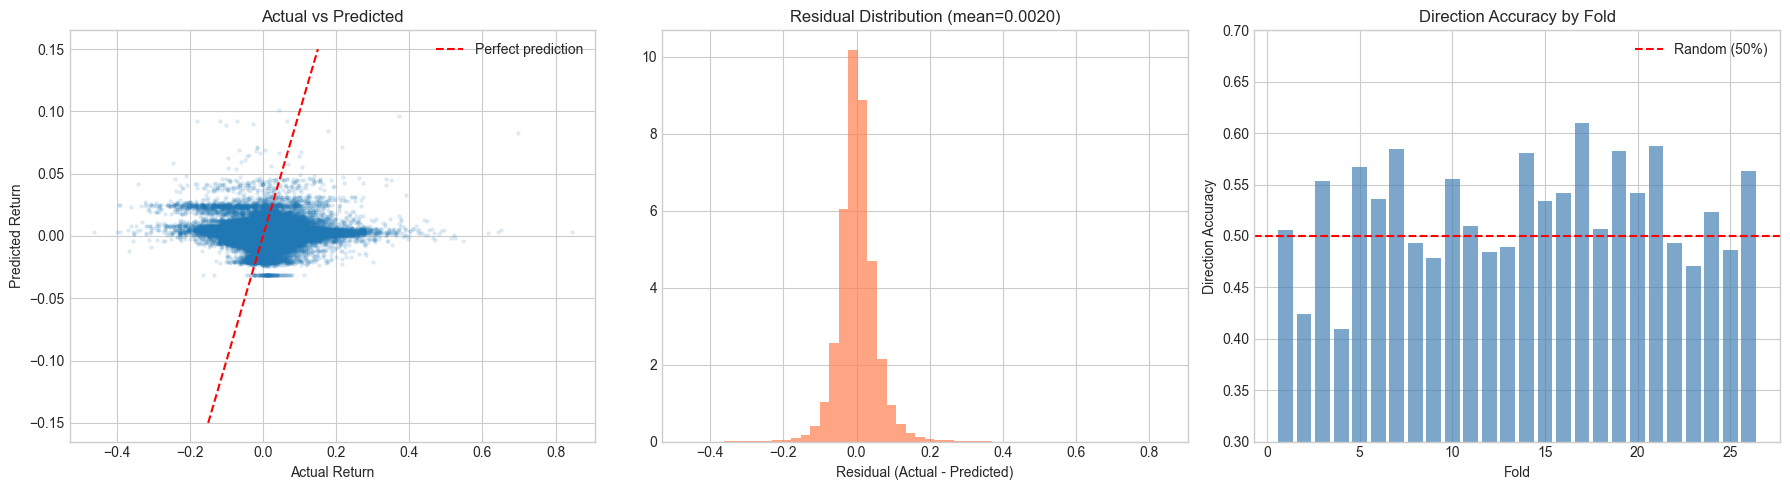

In [6]:
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Actual vs Predicted scatter
    axes[0].scatter(all_preds["actual"], all_preds["predicted"], alpha=0.1, s=5)
    axes[0].plot([-0.15, 0.15], [-0.15, 0.15], "r--", label="Perfect prediction")
    axes[0].set_xlabel("Actual Return")
    axes[0].set_ylabel("Predicted Return")
    axes[0].set_title("Actual vs Predicted")
    axes[0].legend()
    
    # 2. Residual distribution
    residuals = all_preds["actual"] - all_preds["predicted"]
    axes[1].hist(residuals, bins=50, density=True, alpha=0.7, color="coral")
    axes[1].set_xlabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.4f})")
    
    # 3. Metrics by fold
    axes[2].bar(results_df["fold"], results_df["direction_accuracy"],
                color="steelblue", alpha=0.7)
    axes[2].axhline(0.5, color="red", linestyle="--", label="Random (50%)")
    axes[2].set_xlabel("Fold")
    axes[2].set_ylabel("Direction Accuracy")
    axes[2].set_title("Direction Accuracy by Fold")
    axes[2].legend()
    axes[2].set_ylim(0.3, 0.7)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "xgboost_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 6 — Save Model

Save the trained model for use in the ensemble (Notebook 09).

In [7]:
model.save(MODELS_DIR / "xgboost_model.joblib")
print(f"✅ XGBoost model saved to {MODELS_DIR / 'xgboost_model.joblib'}")

# Save predictions for ensemble
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    all_preds.to_parquet(DATA_DIR / "processed" / "xgboost_predictions.parquet")
    print(f"✅ Predictions saved ({len(all_preds)} samples)")

  Saved xgboost to /Users/anto/Trading_Project/masters_trading_ai/models/xgboost_model.joblib
✅ XGBoost model saved to /Users/anto/Trading_Project/masters_trading_ai/models/xgboost_model.joblib
✅ Predictions saved (188457 samples)


## ✅ XGBoost Training Complete!

**Key takeaways:**
- XGBoost trained across all walk-forward folds
- Direction accuracy > 50% indicates the model captures some signal
- R² is typically low for financial returns — this is expected
- Feature importance reveals which technical indicators matter most

**Next:** Proceed to **Notebook 06 — LightGBM Model**

---
*Educational project. Not financial advice.*